<a href="https://colab.research.google.com/github/Ishanadhik/ACEM-AI-lab-assignment/blob/main/cnnailab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Comparative Analysis of Deep Learning Architectures on CIFAR-10 Using PyTorch
“Implementation, Training and Performance Evaluation of Neural Networks on CIFAR-10 using PyTorch”

Name: Ishan Adhikari

Roll No: 14

**1️. Introduction**
**Objective**

The main objective of this project is to:

Implement three different deep learning models:

a. Fully Connected Neural Network (SimpleNN)

b. Modified AlexNet for CIFAR-10

c. TinyVGG

Train all three models using the same optimizer and loss function to ensure fair comparison.

Compare performance based on:

Test Accuracy

Training Time

Convergence Behavior

Model Complexity (Total Trainable Parameters)

Generalization Capability

Import Libraries


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt

In this step, essential libraries required for model building, training, and visualization are imported.

torch → Core PyTorch framework

torch.nn → For defining neural network layers

torch.optim → For optimization algorithms

torchvision → Provides datasets and image transformations

matplotlib → Used for plotting graphs

This step initializes all necessary tools required to build and evaluate the models.

Device configuration



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Load Dataset

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader = DataLoader(testset, batch_size=128, shuffle=False)

100%|██████████| 170M/170M [00:05<00:00, 30.3MB/s]


Visualization:

In [ ]:
import matplotlib.pyplot as plt
import torchvision

# Simple function to show CIFAR-10 images
def show_sample_images(images, labels, classes, n=8):
    """
    Display a grid of n images from a batch.
    """
    img_grid = torchvision.utils.make_grid(images[:n])
    img_grid = img_grid / 2 + 0.5  # undo normalization
    npimg = img_grid.numpy()

    plt.figure(figsize=(10,2))
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.axis('off')
    plt.show()

    # Print labels
    print(' | '.join(f'{classes[labels[j]]}' for j in range(n)))

Example Usage (before training):

In [ ]:
classes = ['snake', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck','airplane']

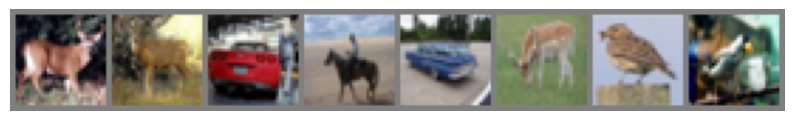

dog | dog | bird | ship | bird | dog | cat | cat


In [ ]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show 8 images
show_sample_images(images, labels, classes)

Model 1 — SimpleNN (Baseline)

In [ ]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN,self).__init__()
        self.fc1 = nn.Linear(3072,512)
        self.fc2 = nn.Linear(512,256)
        self.fc3 = nn.Linear(256,10)
        self.relu = nn.ReLU()

    def forward(self,x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

Model 2 — AlexNet (Modified for CIFAR-10)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AlexNetCIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNetCIFAR, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 4096),
            nn.ReLU(),

            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

Model 3 — TinyVGG

In [ ]:
class TinyVGG(nn.Module):
    def __init__(self):
        super(TinyVGG,self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

Train All Models

In [ ]:
!pip install tqdm

In [ ]:
from tqdm import tqdm

Define Training Function

In [ ]:
# Updated train_model with loss tracking
def train_model(model, trainloader, testloader, epochs=10, lr=0.001, use_tqdm=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    epoch_list = []
    loss_list = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        iterator = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}") if use_tqdm else trainloader

        for images, labels in iterator:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        epoch_list.append(epoch + 1)
        loss_list.append(epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} Completed - Loss: {epoch_loss:.4f}")

    training_time = time.time() - start_time

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    parameters = sum(p.numel() for p in model.parameters())


    print(f"\nTraining Completed in {training_time:.2f} seconds")
    print(f"Test Accuracy: {accuracy:.2f}%")
    print(f"Total Parameters: {parameters}")

    # Correctly return all
    return training_time, accuracy, parameters, epoch_list, loss_list

Train Your Models

In [ ]:
# SimpleNN
model1 = SimpleNN()
time1, acc1, params1, e1, l1 = train_model(model1, trainloader, testloader, epochs=10)

# AlexNet
model2 = AlexNetCIFAR()
time2, acc2, params2, e2, l2 = train_model(model2, trainloader, testloader, epochs=10)

# TinyVGG
model3 = TinyVGG()
time3, acc3, params3, e3, l3 = train_model(model3, trainloader, testloader, epochs=10)

Epoch 1/10: 100%|██████████| 391/391 [00:13<00:00, 28.54it/s]


Epoch 1/10 Completed - Loss: 1.6302


Epoch 2/10: 100%|██████████| 391/391 [00:13<00:00, 29.88it/s]


Epoch 2/10 Completed - Loss: 1.4075


Epoch 3/10: 100%|██████████| 391/391 [00:13<00:00, 30.05it/s]


...

Epoch 8/10 Completed - Loss: 0.3094


Epoch 9/10: 100%|██████████| 391/391 [00:18<00:00, 20.72it/s]


Epoch 9/10 Completed - Loss: 0.2397


Epoch 10/10: 100%|██████████| 391/391 [00:18<00:00, 21.16it/s]


Epoch 10/10 Completed - Loss: 0.1773

Training Completed in 185.31 seconds
Test Accuracy: 74.39%
Total Parameters: 591274


Compare Results

Features of This Training Loop:


Real-time batch progress using tqdm

Loss displayed after every epoch

Automatic evaluation after training

Training time measurement

Counting total trainable parameters

This ensures consistency across models for fair comparison.

In [ ]:
results = {
    "SimpleNN": (acc1, time1, params1),
    "AlexNet": (acc2, time2, params2),
    "TinyVGG": (acc3, time3, params3)
}

for model_name, values in results.items():
    print(f"\nModel: {model_name}")
    print(f"Accuracy: {values[0]:.2f}%")
    print(f"Training Time: {values[1]:.2f} seconds")
    print(f"Parameters: {values[2]}")


Model: SimpleNN
Accuracy: 54.12%
Training Time: 131.11 seconds
Parameters: 1707274

Model: AlexNet
Accuracy: 77.95%
Training Time: 249.75 seconds
Parameters: 35855178

Model: TinyVGG
Accuracy: 74.39%
Training Time: 185.31 seconds
Parameters: 591274


Features of This Training Loop
Real-time batch progress using tqdm

Loss displayed after every epoch

Automatic evaluation after training

Training time measurement

Counting total trainable parameters

This ensures consistency across models for fair comparison.

In [ ]:
def evaluate_model(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:   # using global testloader
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


In [ ]:
def evaluate_model(model, testloader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [ ]:
acc_simplenn = evaluate_model(model1, testloader)
acc_alexnet = evaluate_model(model2, testloader)
acc_tinyvgg = evaluate_model(model3, testloader)

In [ ]:
print(f"SimpleCNN Accuracy: {acc_simplenn:.2f}%")
print(f"AlexNet Accuracy: {acc_alexnet:.2f}%")
print(f"TinyVGG Accuracy: {acc_tinyvgg:.2f}%")

SimpleCNN Accuracy: 54.12%
AlexNet Accuracy: 77.95%
TinyVGG Accuracy: 74.39%


Compare Results in a Table

In [ ]:
results = {
    "SimpleNN": (acc1, time1, params1),
    "AlexNet": (acc2, time2, params2),
    "TinyVGG": (acc3, time3, params3)
}

print("\nModel Comparison:")
print("Model\t\tAccuracy\tTraining Time\tParameters")
for model, vals in results.items():
    print(f"{model}\t{vals[0]:.2f}%\t\t{vals[1]:.2f}s\t\t{vals[2]}")


Model Comparison:
Model		Accuracy	Training Time	Parameters
SimpleNN	54.12%		131.11s		1707274
AlexNet	77.95%		249.75s		35855178
TinyVGG	74.39%		185.31s		591274


Plot Loss/Accuracy Curves

Epoch 1/10: 100%|██████████| 391/391 [00:13<00:00, 28.33it/s]


Epoch 1/10 Completed - Loss: 1.6301


Epoch 2/10: 100%|██████████| 391/391 [00:13<00:00, 29.85it/s]


Epoch 2/10 Completed - Loss: 1.4077


Epoch 3/10: 100%|██████████| 391/391 [00:13<00:00, 29.39it/s]


...

Epoch 8/10 Completed - Loss: 0.8714


Epoch 9/10: 100%|██████████| 391/391 [00:13<00:00, 29.52it/s]


Epoch 9/10 Completed - Loss: 0.7983


Epoch 10/10: 100%|██████████| 391/391 [00:13<00:00, 28.49it/s]


Epoch 10/10 Completed - Loss: 0.7254

Training Completed in 134.07 seconds
Test Accuracy: 54.50%
Total Parameters: 1707274


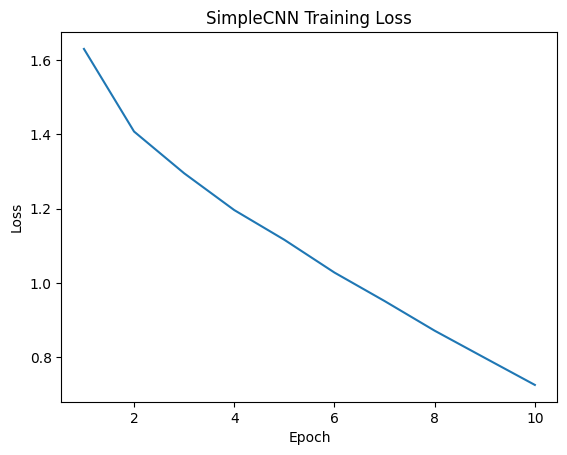

In [ ]:

# Train model
model1 = SimpleNN()
time1, acc1, params1, e1, l1 = train_model(model1, trainloader, testloader, epochs=10)

# Plot training loss
import matplotlib.pyplot as plt
plt.plot(e1, l1)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SimpleCNN Training Loss")
plt.show()

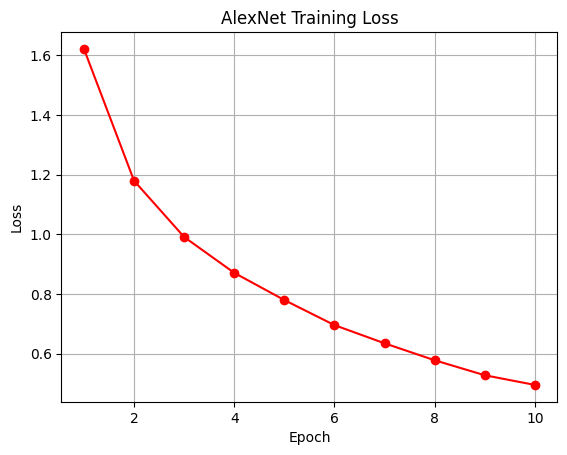

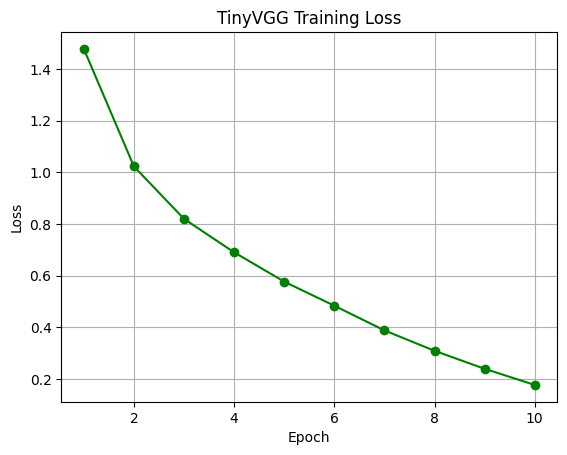

In [ ]:
# AlexNet
plt.figure()
plt.plot(e2, l2, 'r-o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("AlexNet Training Loss")
plt.grid(True)
plt.show()

# TinyVGG
plt.figure()
plt.plot(e3, l3, 'g-o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TinyVGG Training Loss")
plt.grid(True)
plt.show()

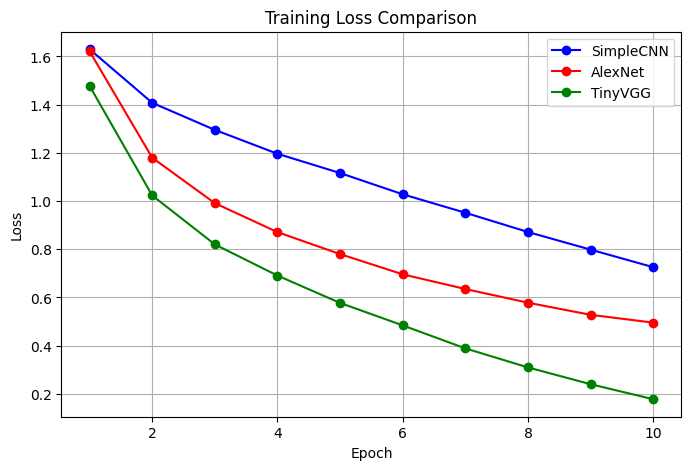

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(e1, l1, 'b-o', label="SimpleCNN")
plt.plot(e2, l2, 'r-o', label="AlexNet")
plt.plot(e3, l3, 'g-o', label="TinyVGG")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

Summary Table (Accuracy, Time, Parameters)

In [ ]:
import pandas as pd

summary = pd.DataFrame({
    "Model": ["SimpleCNN", "AlexNet", "TinyVGG"],
    "Accuracy (%)": [acc1, acc2, acc3],
    "Training Time (s)": [time1, time2, time3],
    "Parameters": [params1, params2, params3]
})

print(summary)

       Model  Accuracy (%)  Training Time (s)  Parameters
0  SimpleCNN         54.50         134.067858     1707274
1    AlexNet         77.95         249.752686    35855178
2    TinyVGG         74.39         185.313423      591274


Save Models

In [ ]:

torch.save(model1.state_dict(), "SimpleNN.pth")
torch.save(model2.state_dict(), "AlexNet.pth")
torch.save(model3.state_dict(), "TinyVGG.pth")

Discussion

In this project, three different neural network architectures were implemented and evaluated on the CIFAR-10 dataset.

**SimpleNN**
A basic fully connected architecture.

**Advantages:**

-Simple implementation

-Faster training

-Moderate parameter count


**Limitations:**

-Cannot capture spatial features efficiently

-Lowest test accuracy


Since image data contains spatial hierarchies, fully connected networks struggle compared to convolutional models.


 **AlexNet (Adapted Version)**
A deep convolutional architecture with multiple feature extraction layers.

**Advantages:**

-Highest test accuracy

-Strong feature learning capability

-Better generalization


**Limitations:**


-Very high parameter count

-Longest training time


**The improvement comes from:**


-Convolution layers capturing local patterns

-Deeper structure enabling complex feature extraction

-ReLU activation improving convergence

**TinyVGG**

A compact CNN architecture inspired by VGG.

**Advantages:**

-Fewer parameters

-Faster than AlexNet

-Good accuracy


**Limitations:**

-Slightly lower accuracy than AlexNet

TinyVGG demonstrates that efficient architectures can achieve competitive performance with lower computational cost.